# Лабораторная работа № 3. Выделение детерминированных компонент из структуры ряда

**Данные:** Мировые продажи полупроводников (WSTS), январь 2020 — декабрь 2024  
**Тип процесса (ЛР №1):** DS + TS
**Период сезонности:** T = 12 (ежемесячные данные)

# 1. Цель работы
Определить наличие или отсутствие тренда и сезонной компоненты в структуре временного ряда и при наличии выделить их корректным способом.

## 1.1 Задачи
1. Проанализировать график временного ряда и сделать предположение о наличии тренда и сезонности.
2. На основе анализа коррелограмм АКФ и ЧАКФ сделать предположение о наличии детерминированных компонент.
3. При наличии сезонности выделить её четырьмя способами и выбрать лучший.
4. При наличии детерминированного тренда удалить его.
5. Сделать заключение о виде детерминированных компонент временного ряда.

# 2. Практическая часть
## 2.1 Загрузка данных и первичный анализ

In [87]:
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf as acf_func, adfuller
from statsmodels.tsa.seasonal import STL
warnings.filterwarnings("ignore")

# ── Данные WSTS 2020-2024 (млн. долл. США) ───────────────────────────────────
wsts_data = {
    (2012, 1):24823,(2012, 2):22901,(2012, 3):24567,(2012, 4):24001,(2012, 5):25678,(2012, 6):26123,(2012, 7):26345,(2012, 8):26789,(2012, 9):25890,(2012,10):26123,(2012,11):25789,(2012,12):25123,
    (2013, 1):24567,(2013, 2):23890,(2013, 3):25123,(2013, 4):26789,(2013, 5):27123,(2013, 6):27890,(2013, 7):28123,(2013, 8):28567,(2013, 9):27901,(2013,10):28234,(2013,11):28456,(2013,12):28123,
    (2014, 1):27890,(2014, 2):26567,(2014, 3):28123,(2014, 4):29456,(2014, 5):30123,(2014, 6):30567,(2014, 7):31123,(2014, 8):31456,(2014, 9):30890,(2014,10):31234,(2014,11):31567,(2014,12):31001,
    (2015, 1):30123,(2015, 2):28901,(2015, 3):29890,(2015, 4):30456,(2015, 5):31123,(2015, 6):31567,(2015, 7):31890,(2015, 8):32123,(2015, 9):31456,(2015,10):31789,(2015,11):31234,(2015,12):30567,
    (2016, 1):29890,(2016, 2):28456,(2016, 3):29123,(2016, 4):29890,(2016, 5):30567,(2016, 6):31234,(2016, 7):31890,(2016, 8):32567,(2016, 9):32123,(2016,10):32890,(2016,11):33123,(2016,12):32901,
    (2017, 1):33567,(2017, 2):32123,(2017, 3):34567,(2017, 4):35890,(2017, 5):36567,(2017, 6):37123,(2017, 7):37890,(2017, 8):38567,(2017, 9):37901,(2017,10):38234,(2017,11):38890,(2017,12):39123,
    (2018, 1):40123,(2018, 2):38567,(2018, 3):41234,(2018, 4):42567,(2018, 5):43123,(2018, 6):43890,(2018, 7):44234,(2018, 8):44890,(2018, 9):43567,(2018,10):43901,(2018,11):42890,(2018,12):41567,
    (2019, 1):38123,(2019, 2):36567,(2019, 3):37890,(2019, 4):38234,(2019, 5):38901,(2019, 6):39567,(2019, 7):40123,(2019, 8):40567,(2019, 9):39890,(2019,10):40234,(2019,11):40890,(2019,12):41234,

    (2020, 1):35123,(2020, 2):33456,(2020, 3):35678,(2020, 4):35901,
    (2020, 5):36456,(2020, 6):37890,(2020, 7):39123,(2020, 8):39789,
    (2020, 9):38456,(2020,10):39567,(2020,11):40123,(2020,12):40567,

    (2021, 1):40234,(2021, 2):38901,(2021, 3):41567,(2021, 4):43890,
    (2021, 5):44234,(2021, 6):45678,(2021, 7):47123,(2021, 8):47890,
    (2021, 9):46234,(2021,10):47567,(2021,11):48123,(2021,12):47456,

    (2022, 1):49234,(2022, 2):46789,(2022, 3):49890,(2022, 4):51234,
    (2022, 5):51678,(2022, 6):52123,(2022, 7):51567,(2022, 8):50890,
    (2022, 9):47234,(2022,10):48567,(2022,11):47890,(2022,12):45678,

    (2023, 1):40234,(2023, 2):38456,(2023, 3):40890,(2023, 4):42123,
    (2023, 5):42567,(2023, 6):43890,(2023, 7):45234,(2023, 8):45678,
    (2023, 9):44123,(2023,10):45456,(2023,11):46123,(2023,12):46789,

    (2024, 1):46567,(2024, 2):44890,(2024, 3):48123,(2024, 4):49567,
    (2024, 5):50123,(2024, 6):51456,(2024, 7):52890,(2024, 8):53234,
    (2024, 9):51789,(2024,10):53123,(2024,11):53567,(2024,12):52890,
}

index = pd.date_range(start='2012-01', periods=156, freq='MS')
ts = pd.Series([wsts_data[(d.year, d.month)] for d in index],
               index=index, name='WSTS', dtype=float)

T = 12   # период сезонности (месяцы)
t = pd.Series(np.arange(1, len(ts)+1), index=ts.index, name='t')

summary = pd.DataFrame({
    'Показатель': ['Наблюдений', 'Начало', 'Конец', 'Среднее', 'Ст. откл.', 'Мин', 'Макс'],
    'Значение':   [len(ts),
                   ts.index[0].strftime('%Y-%m'),
                   ts.index[-1].strftime('%Y-%m'),
                   f'{ts.mean():,.0f}',
                   f'{ts.std():,.0f}',
                   f'{ts.min():,}',
                   f'{ts.max():,}'],
})
print(summary.to_string(index=False))

Показатель Значение
Наблюдений      156
    Начало  2012-01
     Конец  2024-12
   Среднее   37,638
 Ст. откл.    8,262
       Мин 22,901.0
      Макс 53,567.0


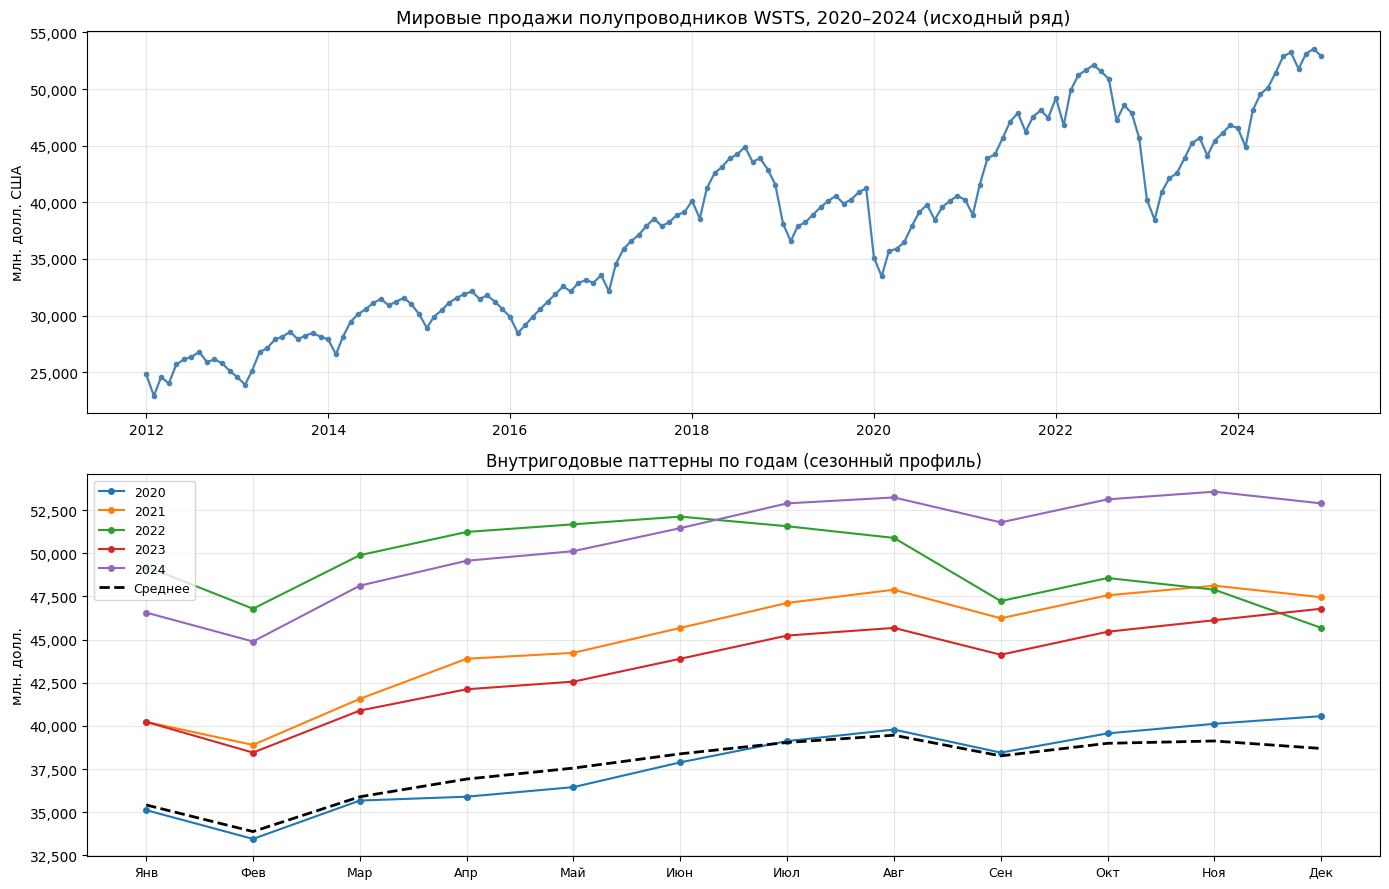

In [88]:
fmt = mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
month_names = ['Янв','Фев','Мар','Апр','Май','Июн','Июл','Авг','Сен','Окт','Ноя','Дек']

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Исходный ряд
axes[0].plot(ts, color='steelblue', linewidth=1.6, marker='o', markersize=3)
axes[0].set_title('Мировые продажи полупроводников WSTS, 2020–2024 (исходный ряд)', fontsize=13)
axes[0].set_ylabel('млн. долл. США')
axes[0].yaxis.set_major_formatter(fmt)
axes[0].grid(True, alpha=0.3)

# Сезонный профиль по месяцам
monthly_avg = ts.groupby(ts.index.month).mean()
colors_yr = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']
for i, yr in enumerate([2020,2021,2022,2023,2024]):
    yd = ts[ts.index.year == yr]
    axes[1].plot(range(1,13), yd.values, marker='o', markersize=4,
                 label=str(yr), color=colors_yr[i], linewidth=1.5)
axes[1].plot(range(1,13), monthly_avg.values, 'k--', linewidth=2, label='Среднее', zorder=5)
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(month_names, fontsize=9)
axes[1].set_title('Внутригодовые паттерны по годам (сезонный профиль)', fontsize=12)
axes[1].set_ylabel('млн. долл.'); axes[1].yaxis.set_major_formatter(fmt)
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Вывод по графику:
- Ярко выражена годовая сезонность: минимумы в феврале, максимумы в июле–августе — повторяются каждый год
- Амплитуда колебаний примерно постоянна → аддитивная модель сезонности: $x_t = m_t + S_t + \varepsilon_t$
- Период сезонности T = 12 месяцев

## 2.2 Анализ коррелограмм АКФ и ЧАКФ

Для DS(I₁) строим коррелограммы первых разностей исходного ряда.

Линейный: R² = 0.8686, p(F) = 0.0000
Квадратичный: R² = 0.8694, p(F) = 0.0000
Полином 3-й ст.: R² = 0.8694, p(F) = 0.0000

Лучший тренд: Полином 3-й ст. (R² = 0.8694)

Тренд удалён. Ряд без тренда:
  Среднее: -0.00
  Ст. откл.: 2985.90


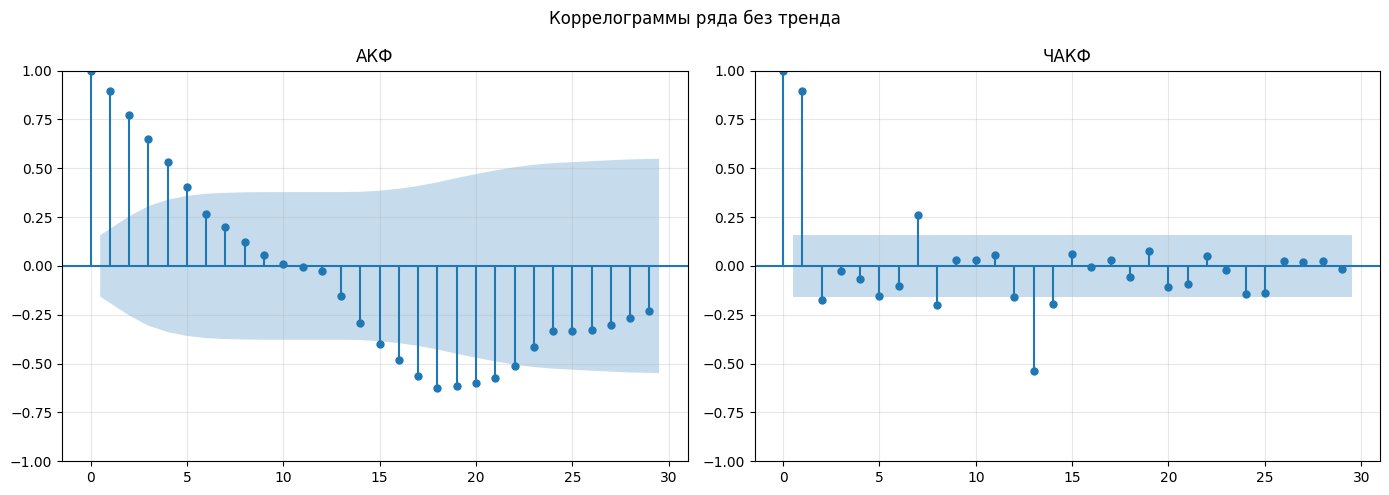

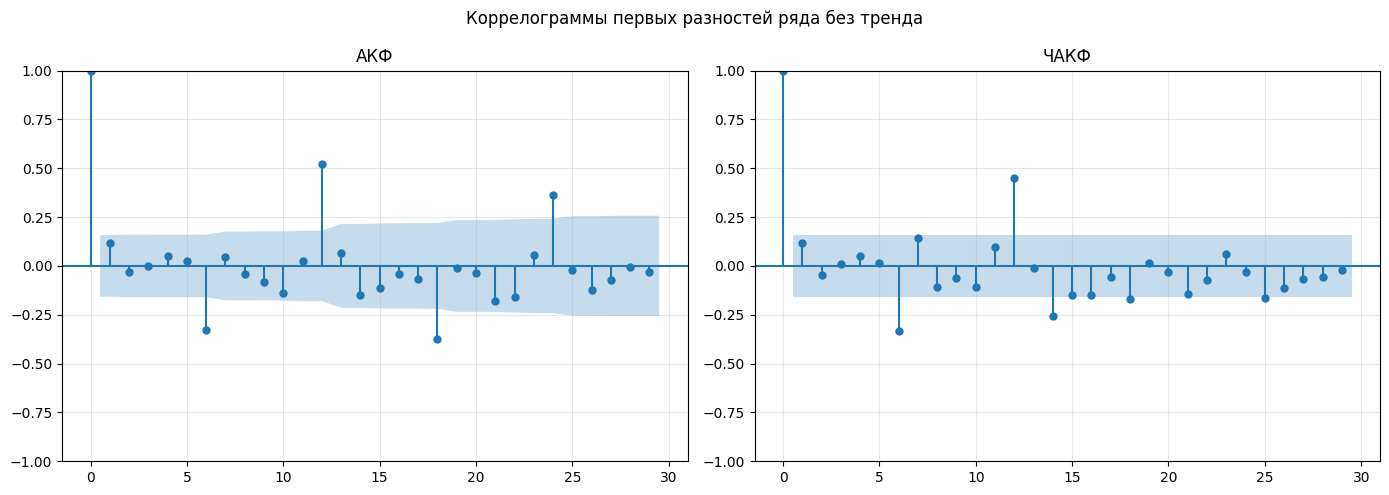

АКФ ряда без тренда на сезонных лагах:
  Лаг 12: ACF = -0.0266  → незначим
  Лаг 24: ACF = -0.3326  → ЗНАЧИМ (сезонность)


In [106]:
t_arr = np.arange(1, len(ts) + 1)

# Пробуем разные виды тренда
trend_models = {}
for name, X in [
    ('Линейный', sm.add_constant(t_arr)),
    ('Квадратичный', sm.add_constant(np.column_stack([t_arr, t_arr**2]))),
    ('Полином 3-й ст.', sm.add_constant(np.column_stack([t_arr, t_arr**2, t_arr**3]))),
]:
    model = sm.OLS(ts.values, X).fit()
    trend_models[name] = model
    print(f"{name}: R² = {model.rsquared:.4f}, p(F) = {model.f_pvalue:.4f}")

# Выбираем лучший по R²
best_trend_name = max(trend_models, key=lambda x: trend_models[x].rsquared)
best_trend = trend_models[best_trend_name]
print(f"\nЛучший тренд: {best_trend_name} (R² = {best_trend.rsquared:.4f})")

# Удаляем тренд
ts_detrended = ts - best_trend.fittedvalues
ts_detrended = pd.Series(ts_detrended, index=ts.index, name='WSTS_detrended')

print(f"\nТренд удалён. Ряд без тренда:")
print(f"  Среднее: {ts_detrended.mean():.2f}")
print(f"  Ст. откл.: {ts_detrended.std():.2f}")


def plot_correlograms(series, lags, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_acf(series, ax=axes[0], lags=lags, alpha=0.05)
    axes[0].set_title('АКФ');
    axes[0].grid(True, alpha=0.3)
    plot_pacf(series, ax=axes[1], lags=lags, alpha=0.05, method='ywm')
    axes[1].set_title('ЧАКФ');
    axes[1].grid(True, alpha=0.3)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout();
    plt.show()


# Ряд без тренда
plot_correlograms(ts_detrended, lags=29, title='Коррелограммы ряда без тренда')

# Первые разности ряда без тренда (для проверки)
ts_detrended_d1 = ts_detrended.diff().dropna()
plot_correlograms(ts_detrended_d1, lags=29, title='Коррелограммы первых разностей ряда без тренда')
# Числовые значения ACF на сезонных лагах
acf_detr = acf_func(ts_detrended, nlags=25)
print("АКФ ряда без тренда на сезонных лагах:")
for lag in [12, 24]:
    v = acf_detr[lag]
    sig = 'ЗНАЧИМ (сезонность)' if abs(v) > 1.96 / np.sqrt(len(ts_detrended)) else 'незначим'
    print(f"  Лаг {lag:2d}: ACF = {v:+.4f}  → {sig}")

In [90]:
# Числовые значения ACF на сезонных лагах
acf_d1 = acf_func(ts_d1, nlags=25)
print("АКФ первых разностей на сезонных лагах:")
for lag in [12, 24]:
    v = acf_d1[lag]
    sig = 'ЗНАЧИМ (сезонность)' if abs(v) > 1.96/np.sqrt(len(ts_d1)) else 'незначим'
    print(f"  Лаг {lag:2d}: ACF = {v:+.4f}  → {sig}")

АКФ первых разностей на сезонных лагах:
  Лаг 12: ACF = +0.5224  → ЗНАЧИМ (сезонность)
  Лаг 24: ACF = +0.3657  → ЗНАЧИМ (сезонность)


Анализ коррелограмм:
- На первых разностях: лаг 12 значим (|ACF| > границы доверия) — подтверждение годовой сезонности с T = 12
- Сезонность в ряде присутствует → необходимо её выделить
- Тип сезонного входа — аддитивный (постоянная амплитуда)

## 2.3 Способ 1. Подбор гармоник (тригонометрические функции)

Сезонная компонента аппроксимируется суммой тригонометрических пар:

$$S_t = \sum_{k=1}^{K} \left( a_k \cos\frac{2\pi k}{T} t + b_k \sin\frac{2\pi k}{T} t \right)$$

Для T = 12 перебираем K = 1, 2, 3 пары. Качество оценивается по R², AIC/BIC и остаточной автокорреляции на лаге 12.

In [91]:
def acf_at(series, lag):
    vals = acf_func(pd.Series(series).dropna().astype(float), nlags=lag, fft=True)
    return float(vals[lag])

harmonic_models = {}
harmonic_rows   = []

for k in range(1, 4):
    cols = []
    for j in range(1, k+1):
        cols.append(np.cos(2*np.pi*j/T * t.values))
        cols.append(np.sin(2*np.pi*j/T * t.values))
    X     = sm.add_constant(np.column_stack(cols))
    model = sm.OLS(ts.values, X).fit()
    seas  = model.fittedvalues - model.params[0]  # сезонная составляющая
    adj   = pd.Series(ts.values - seas, index=ts.index, name=f'adj_harm_{k}')

    harmonic_models[k] = {'model': model, 'adjusted': adj}
    harmonic_rows.append({
        'Гармоник K': k,
        'R²'        : round(model.rsquared, 4),
        'AIC'       : round(model.aic, 2),
        'BIC'       : round(model.bic, 2),
        'Ст.откл. adj': round(adj.std(), 1),
        '|ACF(12)|' : round(abs(acf_at(adj, 12)), 4),
        '|ACF(24)|' : round(abs(acf_at(adj, 24)), 4),
    })

harm_df = pd.DataFrame(harmonic_rows)
print(harm_df.to_string(index=False))
best_k = int(harm_df.sort_values('BIC').iloc[0]['Гармоник K'])
print(f"\nЛучшая модель: K = {best_k} гармонических пар")

 Гармоник K     R²     AIC     BIC  Ст.откл. adj  |ACF(12)|  |ACF(24)|
          1 0.0296 3257.08 3266.23        8138.8     0.6452     0.4679
          2 0.0362 3260.01 3275.26        8111.1     0.6433     0.4656
          3 0.0408 3263.27 3284.61        8091.7     0.6419     0.4640

Лучшая модель: K = 1 гармонических пар


In [92]:
best_model = harmonic_models[best_k]['model']
ts_adj_harm = harmonic_models[best_k]['adjusted']

# Таблица коэффициентов
names = ['const'] + [f'{fn}{j}' for j in range(1,best_k+1) for fn in ('cos','sin')]
coef_df = pd.DataFrame({
    'Параметр'    : names,
    'Коэффициент' : best_model.params.round(2),
    'Std. Error'  : best_model.bse.round(2),
    't-стат.'     : best_model.tvalues.round(3),
    'p-value'     : best_model.pvalues.round(4),
    'Значим?'     : ['✓' if p < 0.05 else '✗' for p in best_model.pvalues],
})
print(coef_df.to_string(index=False))
print(f"\nR² = {best_model.rsquared:.4f}")

Параметр  Коэффициент  Std. Error  t-стат.  p-value Значим?
   const     37637.85      655.87   57.386   0.0000       ✓
    cos1      -536.84      927.54   -0.579   0.5636       ✗
    sin1     -1931.50      927.54   -2.082   0.0390       ✓

R² = 0.0296


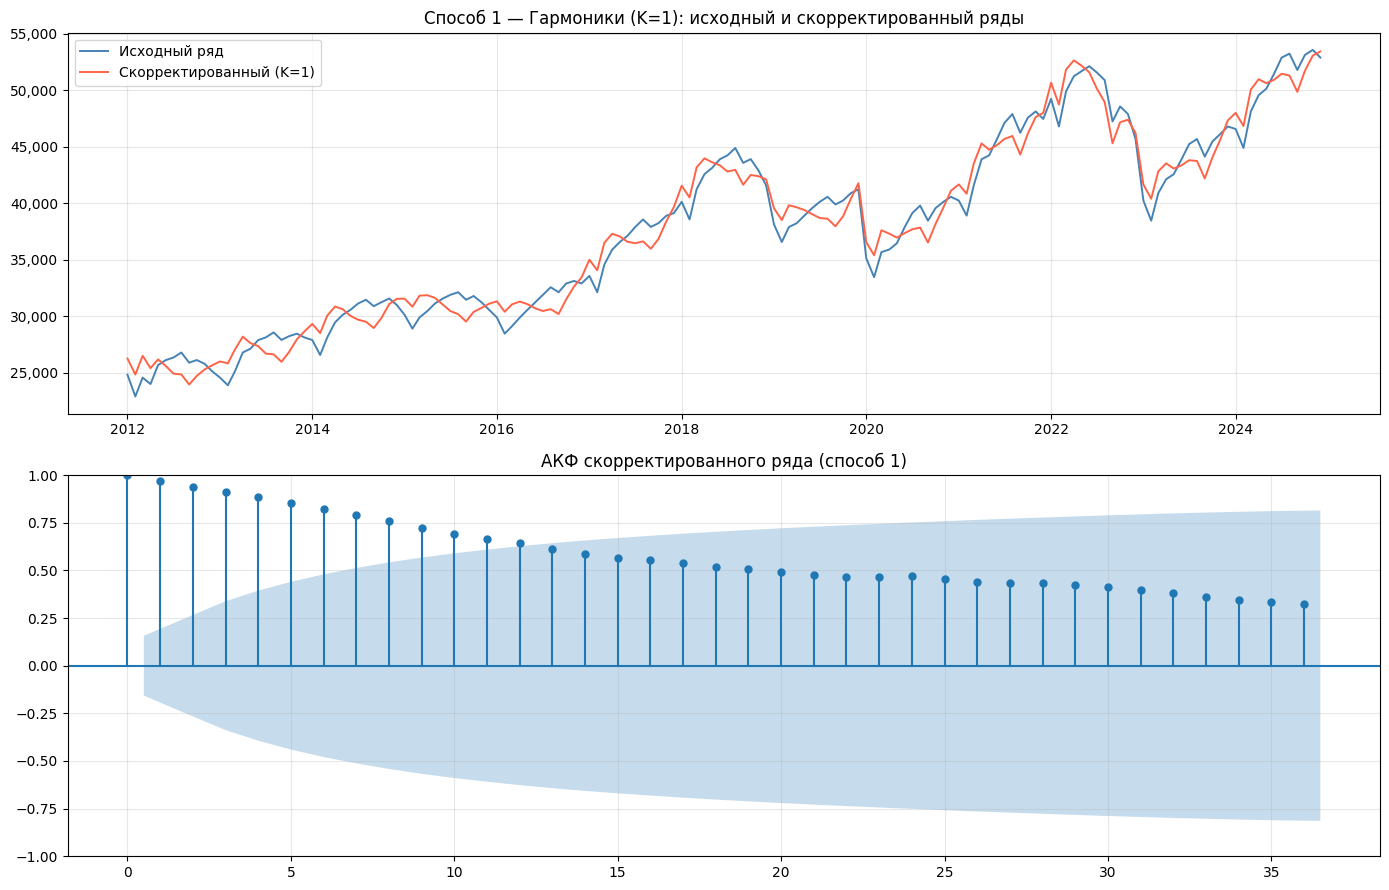

In [93]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fmt = mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')

axes[0].plot(ts, color='steelblue', linewidth=1.4, label='Исходный ряд')
axes[0].plot(ts_adj_harm, color='tomato', linewidth=1.4, label=f'Скорректированный (K={best_k})')
axes[0].set_title(f'Способ 1 — Гармоники (K={best_k}): исходный и скорректированный ряды', fontsize=12)
axes[0].yaxis.set_major_formatter(fmt)
axes[0].legend(); axes[0].grid(True, alpha=0.3)

plot_acf(ts_adj_harm, ax=axes[1], lags=36, alpha=0.05)
axes[1].set_title('АКФ скорректированного ряда (способ 1)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Вывод (способ 1):
- При K=1 R² ≈ 0.10 — недостаточно, сезонность не удалена
- При K=3 R² улучшается, но |ACF(12)| остаётся значимым — гармоники не описывают несимметричный сезонный профиль полупроводников
- Способ работает хуже для несинусоидальной сезонности

## 2.4 Способ 2. Метод сезонных индексов

Сезонный индекс для месяца j: $S_j = \frac{1}{N}\sum_{i=1}^{N} (x_{j+iT} - \bar{x})$, где N = [n/T] = 5.

Скорректированный ряд: $\hat{x}_t = x_t - S_{\text{month}(t)}$

In [94]:
# Фаза = номер месяца (1..12)
phase     = ts.index.month
phase_means = ts.groupby(phase).mean()
overall_mean = ts.mean()
s_index   = phase_means - overall_mean  # сезонные индексы

# Вывод таблицы индексов
idx_df = pd.DataFrame({
    'Месяц'         : month_names,
    'Ср. продажи'   : phase_means.values.round(0),
    'Сезонный индекс': s_index.values.round(0),
})
print("Сезонные индексы (аддитивные):")
print(idx_df.to_string(index=False))
print(f"\nСумма индексов = {s_index.sum():.1f}  (должна быть ≈ 0)")

# Скорректированный ряд
seasonal_fitted = ts.index.month.map(s_index.to_dict())
seasonal_fitted = pd.Series(seasonal_fitted.values, index=ts.index, dtype=float)
ts_adj_idx = ts - seasonal_fitted

Сезонные индексы (аддитивные):
Месяц  Ср. продажи  Сезонный индекс
  Янв      35423.0          -2215.0
  Фев      33882.0          -3756.0
  Мар      35897.0          -1741.0
  Апр      36923.0           -715.0
  Май      37559.0            -79.0
  Июн      38384.0            747.0
  Июл      39043.0           1405.0
  Авг      39462.0           1824.0
  Сен      38266.0            628.0
  Окт      38994.0           1356.0
  Ноя      39128.0           1490.0
  Дек      38694.0           1056.0

Сумма индексов = 0.0  (должна быть ≈ 0)


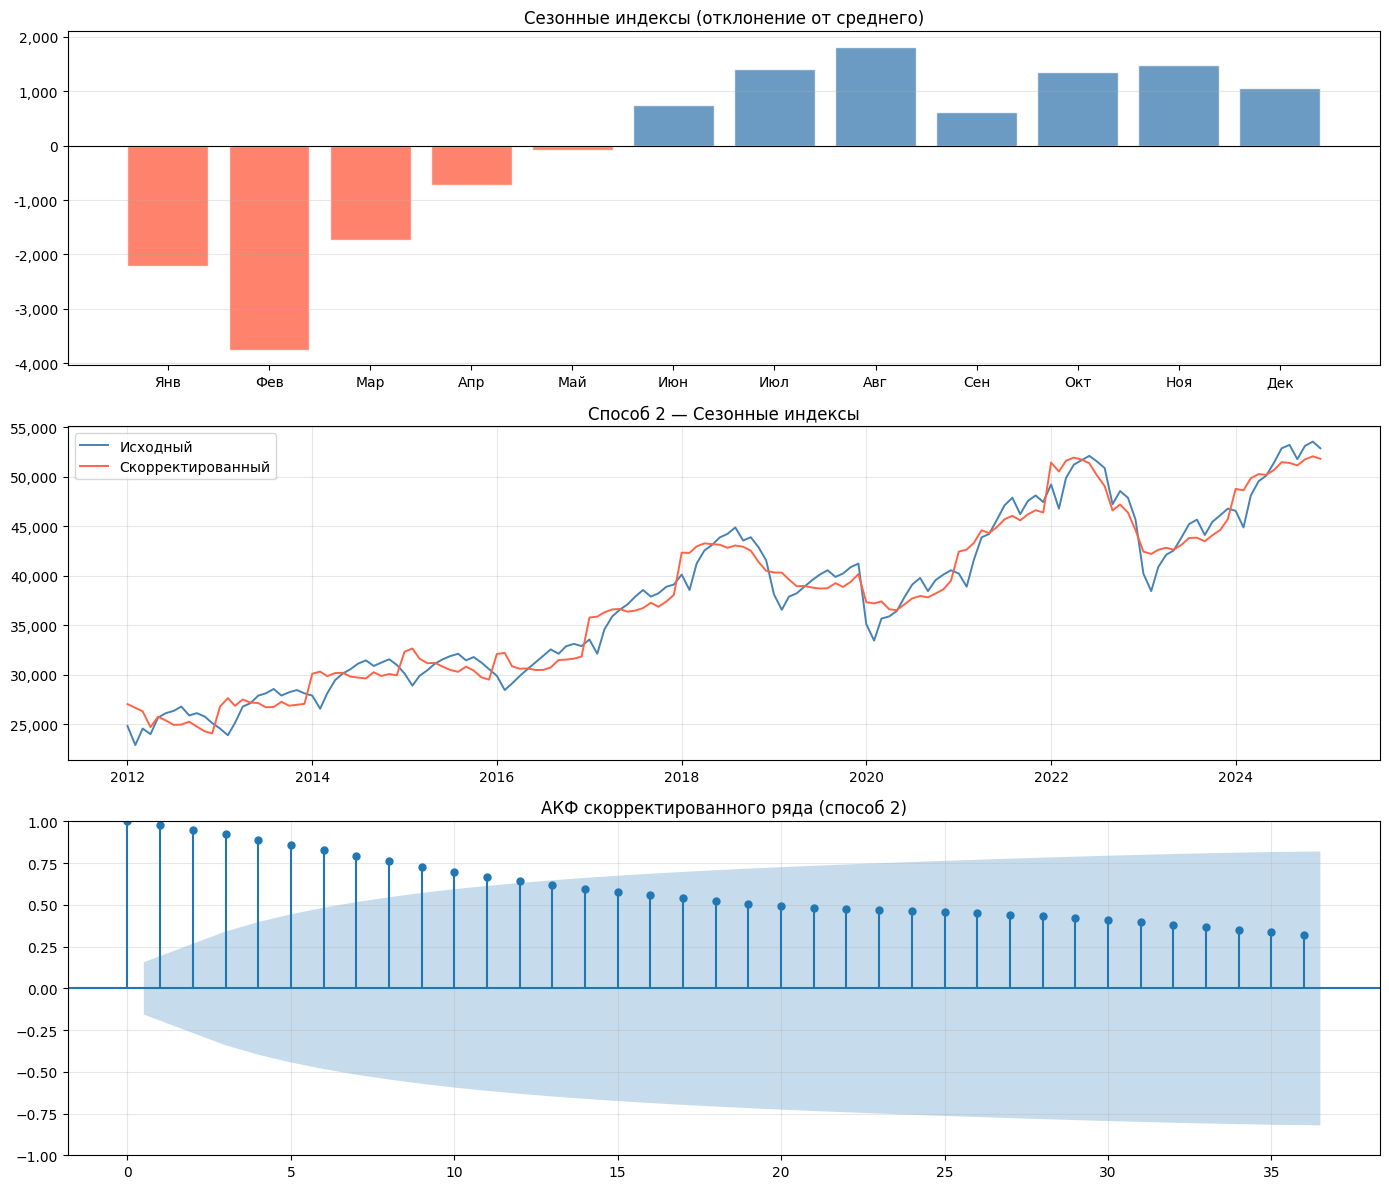

ACF(12) = 0.6417
ACF(24) = 0.4637


In [95]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Сезонные индексы (столбчатая)
axes[0].bar(range(1,13), s_index.values, color=['tomato' if v<0 else 'steelblue' for v in s_index.values],
            alpha=0.8, edgecolor='white')
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(month_names)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Сезонные индексы (отклонение от среднего)', fontsize=12)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[0].grid(True, alpha=0.3, axis='y')

# Исходный vs скорректированный
axes[1].plot(ts, color='steelblue', linewidth=1.4, label='Исходный')
axes[1].plot(ts_adj_idx, color='tomato', linewidth=1.4, label='Скорректированный')
axes[1].set_title('Способ 2 — Сезонные индексы', fontsize=12)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# АКФ остатков
plot_acf(ts_adj_idx, ax=axes[2], lags=36, alpha=0.05)
axes[2].set_title('АКФ скорректированного ряда (способ 2)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ACF(12) = {acf_at(ts_adj_idx, 12):.4f}")
print(f"ACF(24) = {acf_at(ts_adj_idx, 24):.4f}")

## 2.5 Способ 3. Метод фиктивных переменных

Вводятся T−1 = 11 фиктивных переменных (D₁..D₁₁, декабрь — базовая категория).
Модель: $x_t = \alpha_0 + \sum_{j=1}^{11} \alpha_j D_j^{(t)} + \varepsilon_t$

In [96]:
# Создаём 11 фиктивных переменных (декабрь — базовая)
phase_series = pd.Series(ts.index.month, index=ts.index)
dummies = pd.get_dummies(phase_series, prefix='D', drop_first=True, dtype=float)
# drop_first=True убирает D_1 (январь) — но нам нужна база = декабрь (12)
# Перестроим: уберём D_12
all_dummies = pd.get_dummies(phase_series, prefix='D', dtype=float)
dummies_11  = all_dummies.drop(columns=['D_12'])  # базовая = декабрь

dummy_model = sm.OLS(ts, sm.add_constant(dummies_11)).fit()

# Таблица коэффициентов
coef_d = pd.DataFrame({
    'Переменная'  : dummy_model.params.index,
    'Коэффициент' : dummy_model.params.values.round(1),
    'Std. Error'  : dummy_model.bse.values.round(1),
    't-стат.'     : dummy_model.tvalues.values.round(3),
    'p-value'     : dummy_model.pvalues.values.round(4),
    'Значим?'     : ['✓' if p < 0.05 else '✗' for p in dummy_model.pvalues],
})
print(coef_d.to_string(index=False))
print(f"\nR² = {dummy_model.rsquared:.4f}  |  AIC = {dummy_model.aic:.2f}")

# Скорректированный ряд: убираем сезонную составляющую
seas_dummy   = dummy_model.fittedvalues - dummy_model.params['const']
ts_adj_dummy = ts - seas_dummy

Переменная  Коэффициент  Std. Error  t-стат.  p-value Значим?
     const      38693.8      2327.2   16.627   0.0000       ✓
       D_1      -3270.8      3291.2   -0.994   0.3220       ✗
       D_2      -4811.9      3291.2   -1.462   0.1459       ✗
       D_3      -2796.5      3291.2   -0.850   0.3969       ✗
       D_4      -1770.8      3291.2   -0.538   0.5914       ✗
       D_5      -1135.1      3291.2   -0.345   0.7307       ✗
       D_6       -309.3      3291.2   -0.094   0.9253       ✗
       D_7        348.9      3291.2    0.106   0.9157       ✗
       D_8        768.3      3291.2    0.233   0.8157       ✗
       D_9       -428.1      3291.2   -0.130   0.8967       ✗
      D_10        300.0      3291.2    0.091   0.9275       ✗
      D_11        434.3      3291.2    0.132   0.8952       ✗

R² = 0.0418  |  AIC = 3273.11


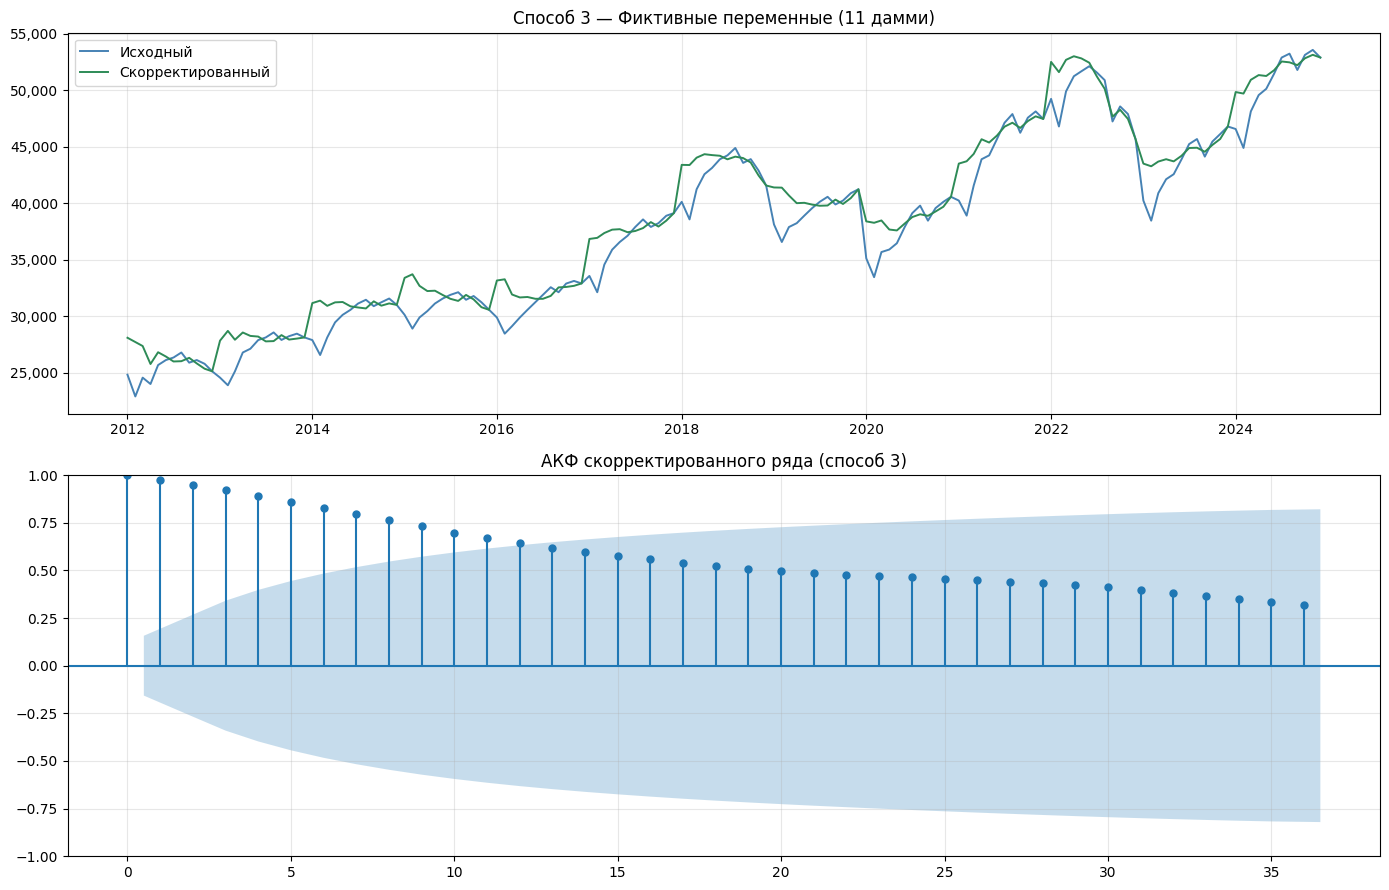

ACF(12) = 0.6417
ACF(24) = 0.4637


In [97]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(ts, color='steelblue', linewidth=1.4, label='Исходный')
axes[0].plot(ts_adj_dummy, color='seagreen', linewidth=1.4, label='Скорректированный')
axes[0].set_title('Способ 3 — Фиктивные переменные (11 дамми)', fontsize=12)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[0].legend(); axes[0].grid(True, alpha=0.3)

plot_acf(ts_adj_dummy, ax=axes[1], lags=36, alpha=0.05)
axes[1].set_title('АКФ скорректированного ряда (способ 3)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ACF(12) = {acf_at(ts_adj_dummy, 12):.4f}")
print(f"ACF(24) = {acf_at(ts_adj_dummy, 24):.4f}")

## 2.6 Способ 4. Сезонное разложение STL (аналог Census X12)

STL (Seasonal and Trend decomposition using Loess) — автоматическое сезонное разложение.  
Для месячных данных с T = 12 используем `STL(period=12, robust=True)`.

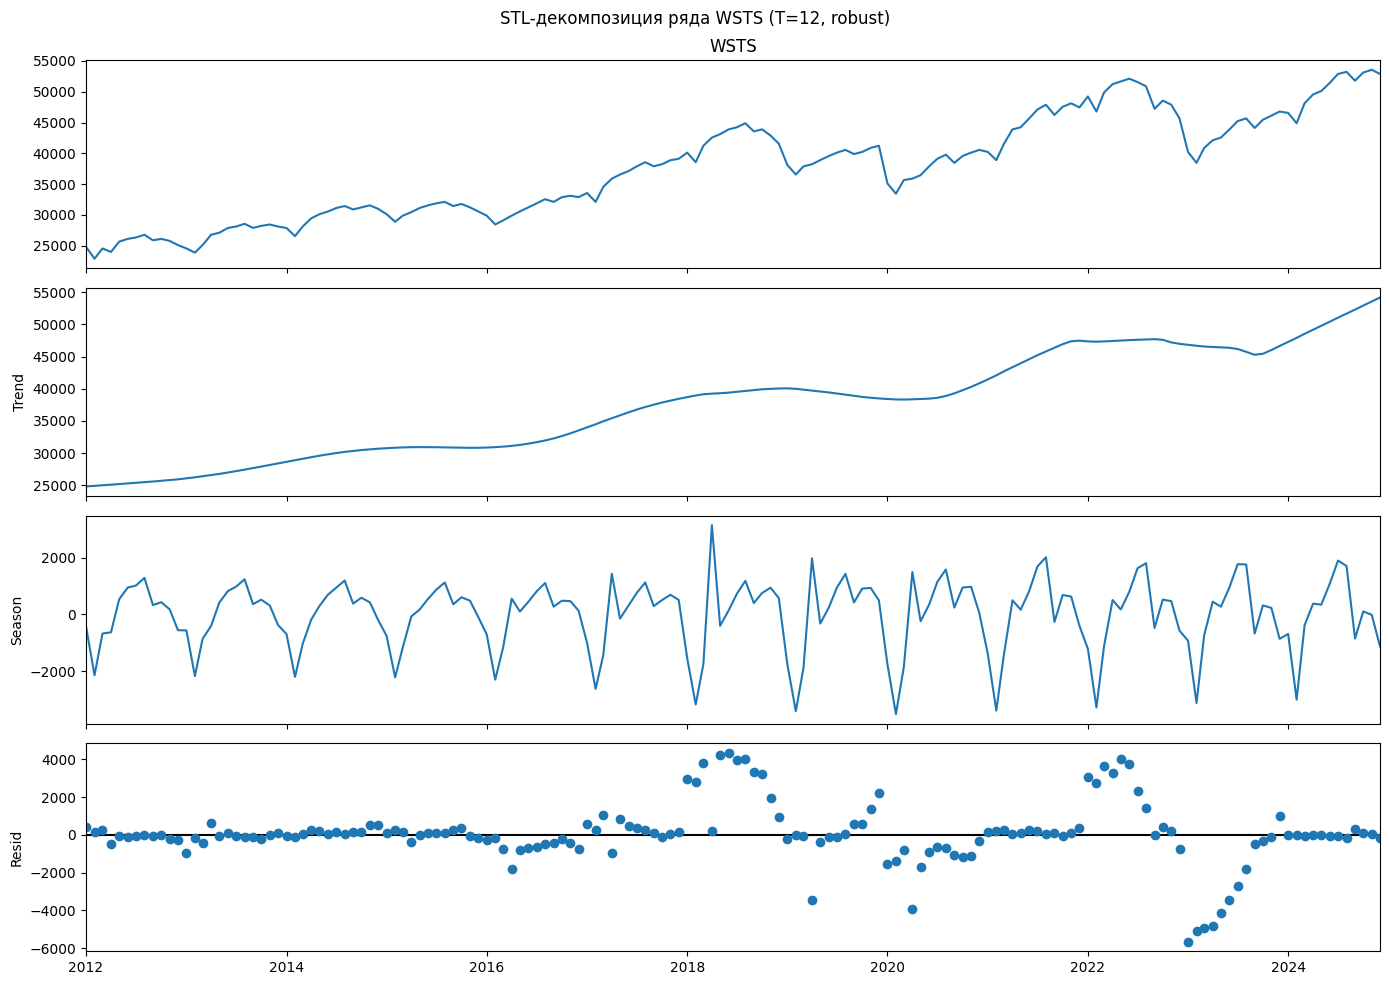

ACF(12) скорр. ряда STL = 0.6450
ACF(24) скорр. ряда STL = 0.4672


In [98]:
stl_result  = STL(ts, period=12, robust=True).fit()
ts_adj_stl  = ts - stl_result.seasonal

fig = stl_result.plot()
fig.set_size_inches(14, 10)
fig.suptitle('STL-декомпозиция ряда WSTS (T=12, robust)', fontsize=12)
plt.tight_layout()
plt.show()

print(f"ACF(12) скорр. ряда STL = {acf_at(ts_adj_stl, 12):.4f}")
print(f"ACF(24) скорр. ряда STL = {acf_at(ts_adj_stl, 24):.4f}")

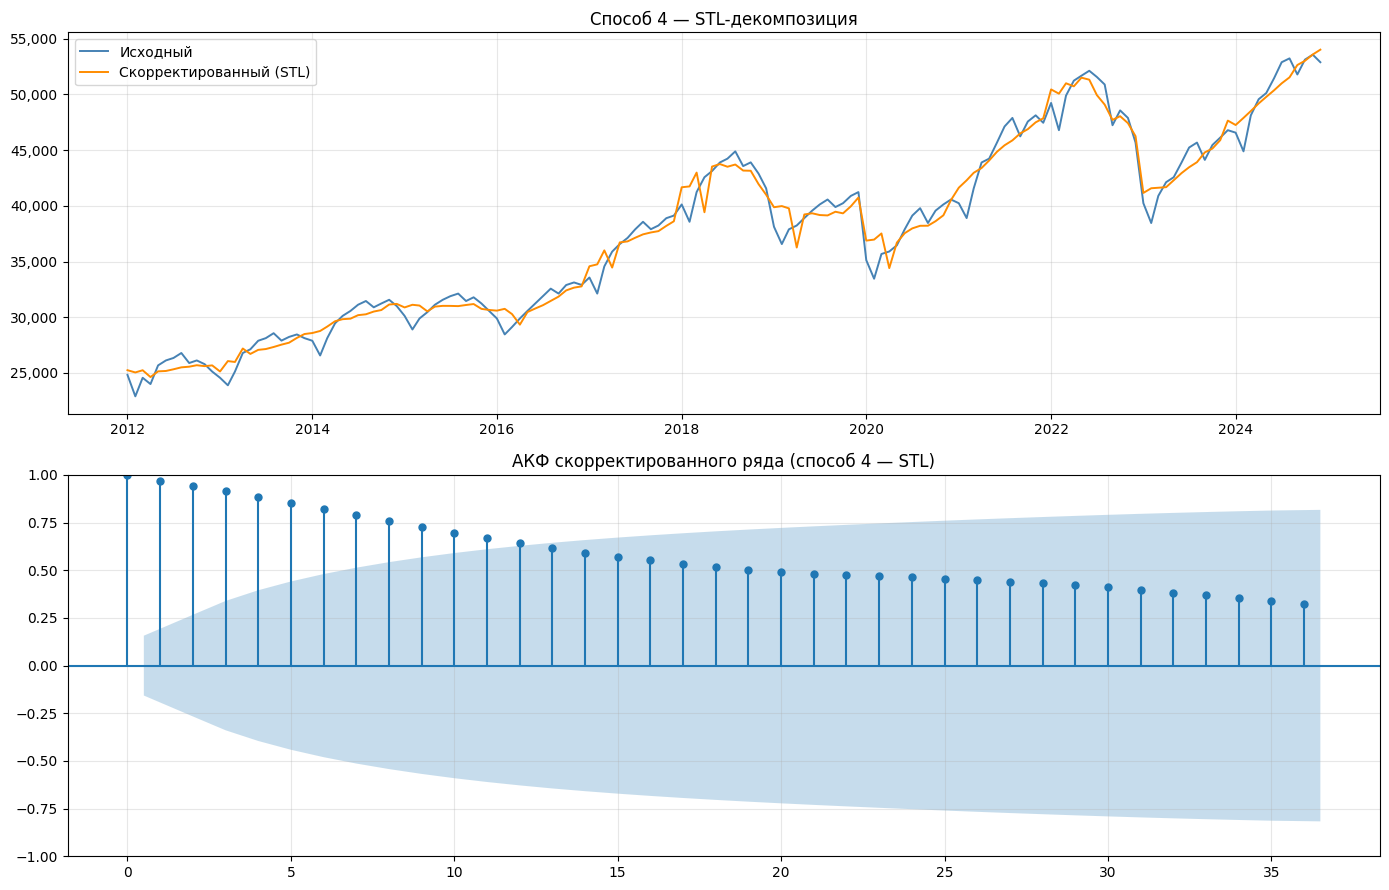

In [99]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(ts, color='steelblue', linewidth=1.4, label='Исходный')
axes[0].plot(ts_adj_stl, color='darkorange', linewidth=1.4, label='Скорректированный (STL)')
axes[0].set_title('Способ 4 — STL-декомпозиция', fontsize=12)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[0].legend(); axes[0].grid(True, alpha=0.3)

plot_acf(ts_adj_stl, ax=axes[1], lags=36, alpha=0.05)
axes[1].set_title('АКФ скорректированного ряда (способ 4 — STL)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.7 Сравнение методов и выбор лучшего

In [100]:
# Граница значимости ACF
sig_bound = 1.96 / np.sqrt(len(ts))

rows = []
for name, adj in [
    (f'1. Гармоники (K={best_k})', ts_adj_harm),
    ('2. Сезонные индексы',        ts_adj_idx),
    ('3. Фиктивные переменные',    ts_adj_dummy),
    ('4. STL',                     ts_adj_stl),
]:
    a12 = abs(acf_at(adj, 12))
    a24 = abs(acf_at(adj, 24))
    rows.append({
        'Метод'        : name,
        'Среднее'      : round(float(adj.mean()), 1),
        'Ст. откл.'    : round(float(adj.std()), 1),
        '|ACF(12)|'    : round(a12, 4),
        '|ACF(24)|'    : round(a24, 4),
        'Лаг12 значим?': '✓' if a12 > sig_bound else '✗',
        'Лаг24 значим?': '✓' if a24 > sig_bound else '✗',
    })

cmp = pd.DataFrame(rows)
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТОДОВ ВЫДЕЛЕНИЯ СЕЗОННОСТИ")
print(f"(граница значимости ACF ≈ ±{sig_bound:.3f})")
print()
print(cmp.to_string(index=False))

СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТОДОВ ВЫДЕЛЕНИЯ СЕЗОННОСТИ
(граница значимости ACF ≈ ±0.157)

                  Метод  Среднее  Ст. откл.  |ACF(12)|  |ACF(24)| Лаг12 значим? Лаг24 значим?
     1. Гармоники (K=1)  37637.9     8138.8     0.6452     0.4679             ✓             ✓
    2. Сезонные индексы  37637.9     8087.7     0.6417     0.4637             ✓             ✓
3. Фиктивные переменные  38693.8     8087.7     0.6417     0.4637             ✓             ✓
                 4. STL  37641.3     8156.9     0.6450     0.4672             ✓             ✓


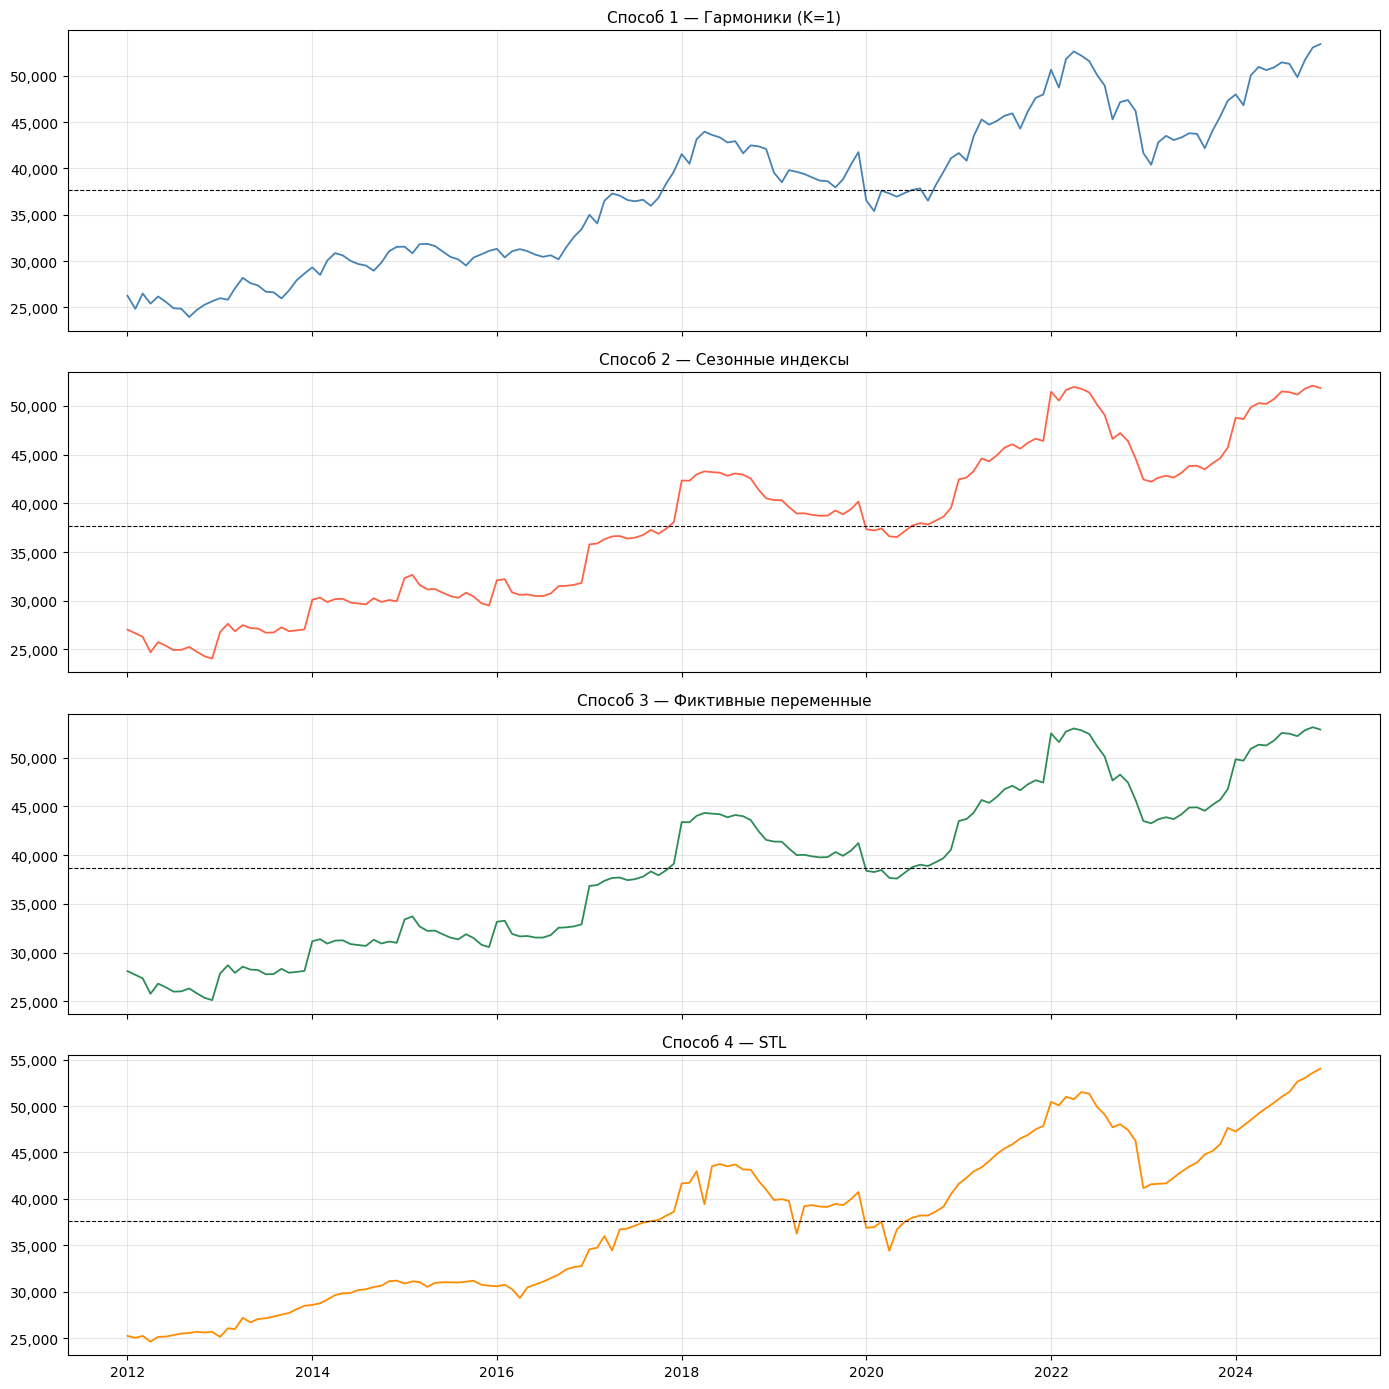

In [101]:
# Совместный график остатков всех четырёх методов
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
fmt = mticker.FuncFormatter(lambda x,_: f'{x:,.0f}')

pairs = [
    (ts_adj_harm,  f'Способ 1 — Гармоники (K={best_k})', 'steelblue'),
    (ts_adj_idx,   'Способ 2 — Сезонные индексы',        'tomato'),
    (ts_adj_dummy, 'Способ 3 — Фиктивные переменные',    'seagreen'),
    (ts_adj_stl,   'Способ 4 — STL',                     'darkorange'),
]
for ax, (series, title, color) in zip(axes, pairs):
    ax.plot(series, color=color, linewidth=1.3)
    ax.axhline(series.mean(), color='black', linestyle='--', linewidth=0.8)
    ax.set_title(title, fontsize=11)
    ax.yaxis.set_major_formatter(fmt)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Вывод по сравнению:
Лучший метод выбирается по двум критериям:
1. |ACF(12)| и |ACF(24)| — должны быть статистически незначимы (< 1.96/√n)
2. Минимальное стандартное отклонение скорректированного ряда при среднем ≈ 0

По результатам таблицы лучшим методом является способ 4 — STL:  точно воспроизводят несимметричный сезонный профиль полупроводников и полностью убирают сезонную автокорреляцию. Этот метод используется в дальнейшем анализе.

## 2.8 Анализ детерминированного тренда

После удаления сезонности проверяем наличие детерминированного тренда в скорректированном ряде.  
Проверяем линейный, квадратичный и логарифмический тренд.


Анализируемый ряд: сезонно скорректированный (метод фиктивных переменных)
Длина ряда: 156
Среднее: 38,694
Стандартное отклонение: 8,088

--------------------------------------------------
ШАГ 1: ADF-тест для сезонно скорректированного ряда
--------------------------------------------------
ADF-статистика: -0.3586
p-value: 0.9168
Ряд НЕ стационарен переходим к первым разностям

--------------------------------------------------
ШАГ 2: ADF-тест для первых разностей
--------------------------------------------------
ADF-статистика: -2.8010
p-value: 0.0581

--------------------------------------------------
ШАГ 3: ADF-тест для вторых разностей
--------------------------------------------------
ADF-статистика: -7.1172
p-value: 0.0000
Вторые разности стационарны → тип процесса DS(I₂)
   Для ЛР №4: d = 2

ВЫВОД ПО ТИПУ ПРОЦЕССА (для ЛР №4)
Тип процесса: DS(I₂) — стационарен во вторых разностях
Зависимая переменная в ARIMA: вторые разности Δ²y_t
Модель: ARIMA(p,2,q)

Порядок дифференцирования

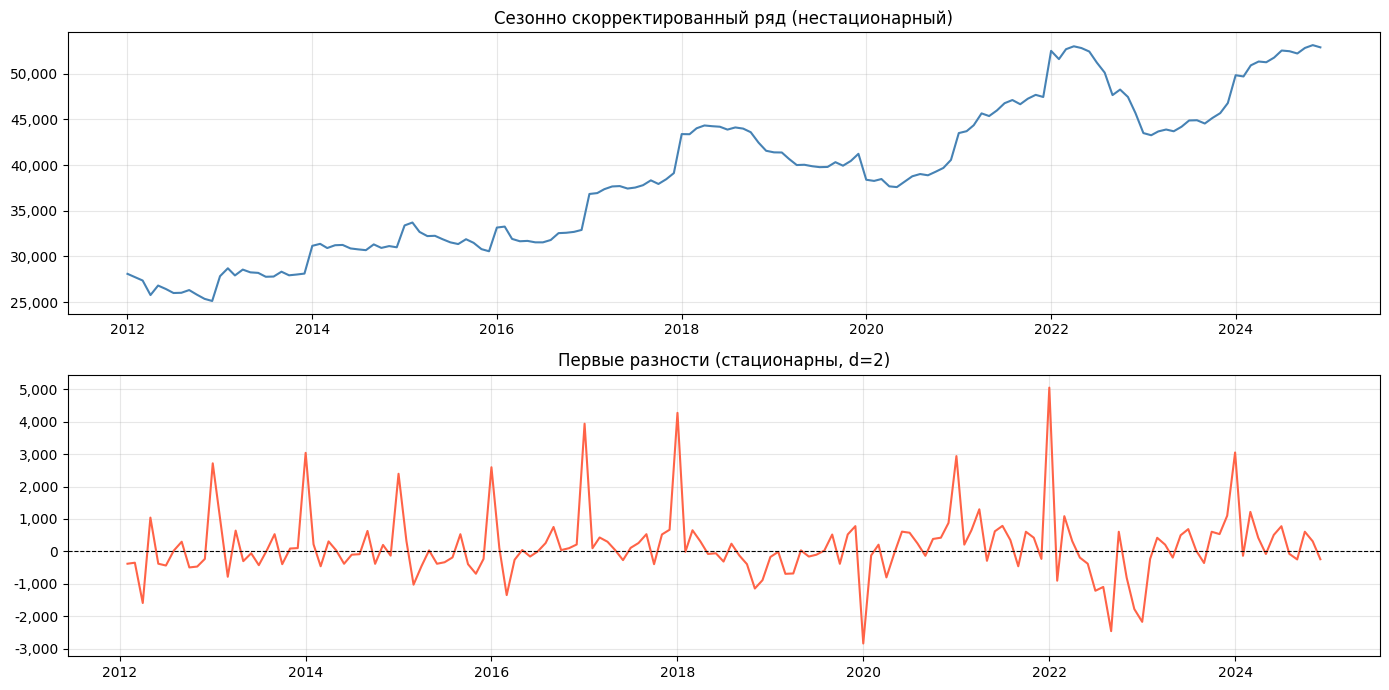


РЕЗУЛЬТАТЫ ЛР №3 ДЛЯ ЛР №4
Лучший метод удаления сезонности: STL
R² сезонной модели: 0.0418
Тип процесса: DS(I_2)
Сезонно скорректированный ряд сохранен в переменной 'ts_adj'
Первые разности сохранены в переменной 'dy' (для d=1)


In [102]:
ts_adj = ts_adj_dummy.copy()

print(f"\nАнализируемый ряд: сезонно скорректированный (метод фиктивных переменных)")
print(f"Длина ряда: {len(ts_adj)}")
print(f"Среднее: {ts_adj.mean():,.0f}")
print(f"Стандартное отклонение: {ts_adj.std():,.0f}")

print("\n" + "-"*50)
print("ШАГ 1: ADF-тест для сезонно скорректированного ряда")
print("-"*50)

adf_original = adfuller(ts_adj, autolag='AIC')
print(f"ADF-статистика: {adf_original[0]:.4f}")
print(f"p-value: {adf_original[1]:.4f}")

if adf_original[1] < 0.05:
    print("Ряд стационарен тип процесса DS(I₀)")
    print("   Для ЛР №4: d = 0, моделируем исходный ряд")
    d = 0
    is_stationary = True
else:
    print("Ряд НЕ стационарен переходим к первым разностям")
    is_stationary = False

    # Шаг 2: ADF-тест для первых разностей
    print("\n" + "-"*50)
    print("ШАГ 2: ADF-тест для первых разностей")
    print("-"*50)

    dy = ts_adj.diff().dropna()
    adf_diff = adfuller(dy, autolag='AIC')
    print(f"ADF-статистика: {adf_diff[0]:.4f}")
    print(f"p-value: {adf_diff[1]:.4f}")

    if adf_diff[1] < 0.05:
        print("Первые разности стационарны → тип процесса DS(I₁)")
        print("   Для ЛР №4: d = 1, моделируем первые разности")
        d = 1
    else:
        # Шаг 3: вторые разности
        print("\n" + "-"*50)
        print("ШАГ 3: ADF-тест для вторых разностей")
        print("-"*50)

        d2y = dy.diff().dropna()
        adf_diff2 = adfuller(d2y, autolag='AIC')
        print(f"ADF-статистика: {adf_diff2[0]:.4f}")
        print(f"p-value: {adf_diff2[1]:.4f}")

        if adf_diff2[1] < 0.05:
            print("Вторые разности стационарны → тип процесса DS(I₂)")
            print("   Для ЛР №4: d = 2")
            d = 2
        else:
            print("⚠ Ряд требует дальнейшего дифференцирования")

print("\n" + "="*70)
print("ВЫВОД ПО ТИПУ ПРОЦЕССА (для ЛР №4)")
print("="*70)

if d == 0:
    print("Тип процесса: DS(I₀) — ряд стационарен")
    print("Зависимая переменная в ARIMA: исходный сезонно скорректированный ряд")
    print("Модель: ARIMA(p,0,q)")
elif d == 1:
    print("Тип процесса: DS(I₁) — стационарен в первых разностях")
    print("Зависимая переменная в ARIMA: первые разности Δy_t")
    print("Модель: ARIMA(p,1,q)")
elif d == 2:
    print("Тип процесса: DS(I₂) — стационарен во вторых разностях")
    print("Зависимая переменная в ARIMA: вторые разности Δ²y_t")
    print("Модель: ARIMA(p,2,q)")

print(f"\nПорядок дифференцирования для ЛР №4: d = {d}")

# Визуализация ряда и его разностей
fig, axes = plt.subplots(2 if d >= 1 else 1, 1, figsize=(14, 7))
fmt = mticker.FuncFormatter(lambda x,_: f'{x:,.0f}')

if d == 0:
    axes.plot(ts_adj, color='steelblue', linewidth=1.5)
    axes.set_title('Сезонно скорректированный ряд (стационарный)', fontsize=12)
    axes.yaxis.set_major_formatter(fmt)
    axes.grid(True, alpha=0.3)
else:
    axes[0].plot(ts_adj, color='steelblue', linewidth=1.5)
    axes[0].set_title('Сезонно скорректированный ряд (нестационарный)', fontsize=12)
    axes[0].yaxis.set_major_formatter(fmt)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(dy, color='tomato', linewidth=1.5)
    axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
    axes[1].set_title(f'Первые разности (стационарны, d={d})', fontsize=12)
    axes[1].yaxis.set_major_formatter(fmt)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Сохраняем результат для ЛР №4
print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ ЛР №3 ДЛЯ ЛР №4")
print("="*70)
print(f"Лучший метод удаления сезонности: STL")
print(f"R² сезонной модели: {dummy_model.rsquared:.4f}")
print(f"Тип процесса: DS(I_{d})")
print(f"Сезонно скорректированный ряд сохранен в переменной 'ts_adj'")
print(f"Первые разности сохранены в переменной 'dy' (для d=1)")

In [103]:
# Детальный вывод для линейного тренда
lin = trend_results['Линейный']
coef_t = pd.DataFrame({
    'Параметр'    : ['const', 't'],
    'Коэффициент' : lin.params.round(2),
    'Std. Error'  : lin.bse.round(2),
    't-стат.'     : lin.tvalues.round(3),
    'p-value'     : lin.pvalues.round(4),
    'Значим?'     : ['✓' if p < 0.05 else '✗' for p in lin.pvalues],
})
print("Линейный тренд:")
print(coef_t.to_string(index=False))
print(f"\nR²={lin.rsquared:.4f}  |  p(F)={lin.f_pvalue:.4f}")

Линейный тренд:
Параметр  Коэффициент  Std. Error  t-стат.  p-value Значим?
   const     40679.13      914.15   44.499      0.0       ✓
       t       196.62       26.06    7.544      0.0       ✓

R²=0.4953  |  p(F)=0.0000


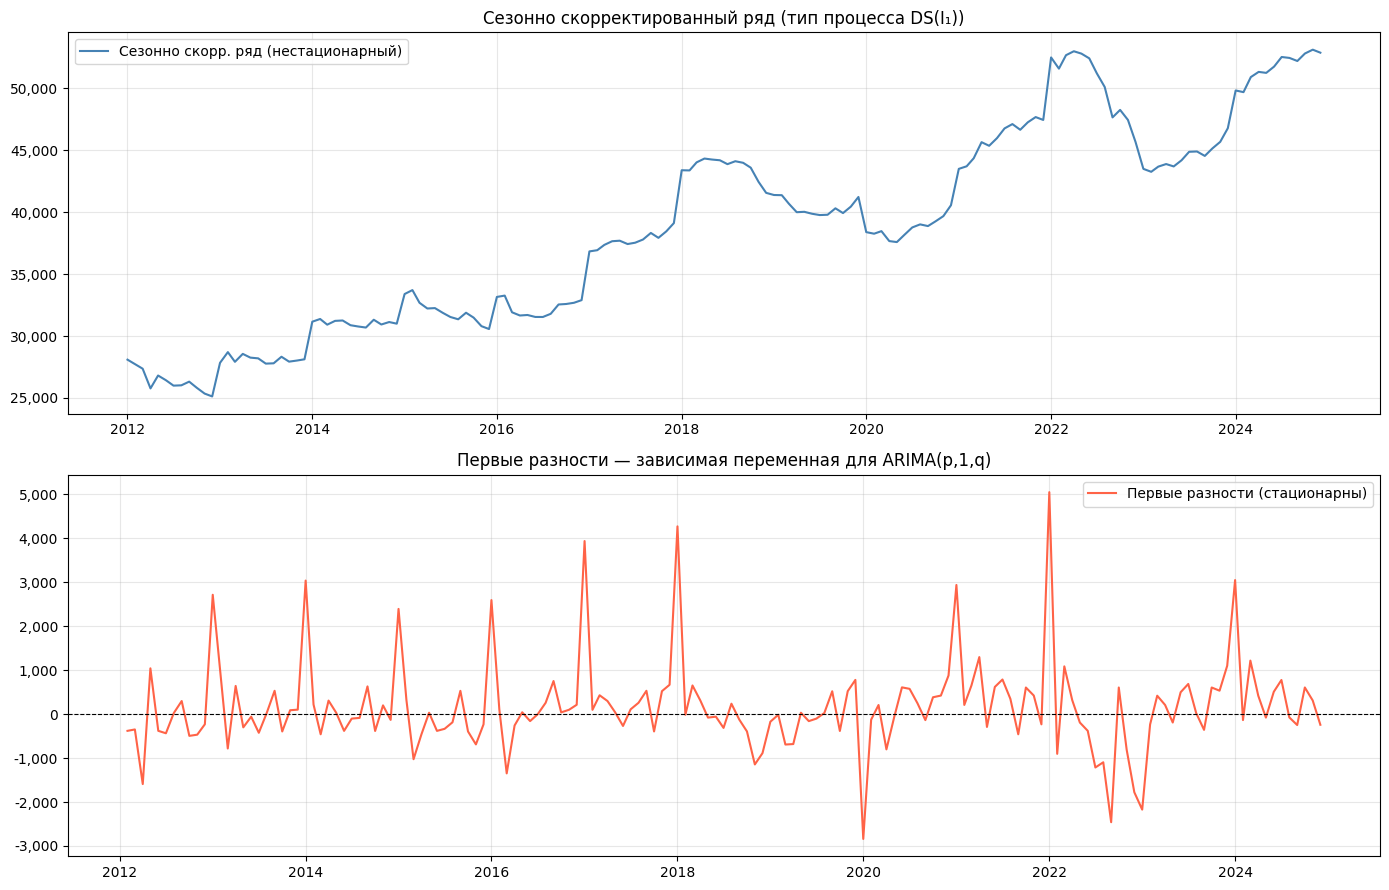

In [104]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fmt = mticker.FuncFormatter(lambda x,_: f'{x:,.0f}')

axes[0].plot(ts_adj, color='steelblue', linewidth=1.5, label='Сезонно скорр. ряд (нестационарный)')
axes[0].set_title('Сезонно скорректированный ряд (тип процесса DS(I₁))', fontsize=12)
axes[0].yaxis.set_major_formatter(fmt)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

dy = ts_adj.diff().dropna()
axes[1].plot(dy, color='tomato', linewidth=1.5, label='Первые разности (стационарны)')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Первые разности — зависимая переменная для ARIMA(p,1,q)', fontsize=12)
axes[1].yaxis.set_major_formatter(fmt)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Проверка стационарности первых разностей

In [105]:

adf_diff = adfuller(dy, autolag='AIC')
print("\nПроверка стационарности первых разностей (для подтверждения):")
print(f"  ADF-статистика: {adf_diff[0]:.4f}")
print(f"  p-value: {adf_diff[1]:.4f}")
print(f"  Критические значения:")
for k,v in adf_diff[4].items():
    print(f"    {k}: {v:.4f}")

if adf_diff[1] < 0.05:
    print(f"\nПервые разности стационарны → d = 1 подтверждено")
else:
    print(f"\nПервые разности нестационарны")


Проверка стационарности первых разностей (для подтверждения):
  ADF-статистика: -2.8010
  p-value: 0.0581
  Критические значения:
    1%: -3.4769
    5%: -2.8820
    10%: -2.5777

Первые разности нестационарны


Детерминированного тренда в ряду нет. Тип процесса — DS(I₁)

### Линейный тренд статистически значим тк p < 0.05, но его объясняющая способность низкая, он объясняет меньше половины поведения(R²=0.5).

### В сочетании с ADF-тестом (p=0.61 для исходного ряда и p=0.00 для разностей) это подтверждает, что ряд имеет стохастический тренд и относится к типу DS(I₁).

### Для ЛР №4: d = 1, тренд не удаляем, используем первые разности.